# 🔍 Social Welfare Payment Fraud Detection: ML for Government Integrity

**Author:** Dean | Lead Data & AI Engineer  
**Focus:** Detecting fraudulent transactions/claims to protect government payment integrity  
**Series:** Production ML Portfolio — Australian Government Policy Applications

---

## Executive Summary

This notebook demonstrates a production-grade ML pipeline for detecting fraudulent transactions using customer profiles, transaction patterns, and behavioural indicators. The model supports **automated fraud screening** for government payment systems, reducing improper payments while protecting legitimate recipients.

### Government Policy Context
- **Services Australia** — Centrelink payment integrity, Medicare compliance, Child Support fraud detection
- **DSS (Dept of Social Services)** — Welfare payment policy, income support compliance framework
- **NDIS Quality & Safeguards Commission** — Provider fraud detection, plan misuse identification
- **Attorney-General's Dept** — Commonwealth Fraud Prevention Centre, Fraud Rule 2017
- **ANAO (Australian National Audit Office)** — Payment integrity audits, improper payment reporting

### Operational Decision Framework
| Prediction | Action | Stakeholder |
|-----------|--------|-------------|
| Fraud (high confidence) | Suspend payment, refer to Fraud Investigation Branch | Compliance team |
| Fraud (borderline) | Enhanced verification, request documentation | Case officer |
| Legitimate (confident) | Standard processing, routine monitoring | Automated system |
| Legitimate (risk factors) | Periodic review, data matching check | Compliance analytics |

### Ethical Considerations
This model must be deployed with extreme care. The Robodebt Royal Commission highlighted the devastating impact of incorrect fraud determinations on vulnerable Australians. All automated decisions must include human review, appeal rights, and fairness monitoring across demographics.

---


## 1. Data Loading & Initial Assessment

In [1]:
import os
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        full_path = os.path.join(root, f)
        size = os.path.getsize(full_path)
        print(f"  {size:>8,} bytes | {full_path}")

  150,828,752 bytes | /kaggle/input/datasets/whenamancodes/fraud-detection/creditcard.csv


In [2]:
import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, roc_auc_score, precision_score,
                             recall_score, brier_score_loss)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print("=" * 60)
print("ENVIRONMENT READY")
print("=" * 60)


ENVIRONMENT READY


In [3]:
data_path = None
all_csvs = []
print("Scanning /kaggle/input...")
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        full_path = os.path.join(root, f)
        print(f"  Found: {full_path}")
        if f.endswith('.csv'):
            all_csvs.append(full_path)

if len(all_csvs) == 0:
    raise FileNotFoundError("No CSV found")
elif len(all_csvs) == 1:
    data_path = all_csvs[0]
else:
    sizes = {p: os.path.getsize(p) for p in all_csvs}
    data_path = max(sizes, key=sizes.get)
    print(f"\nMultiple CSVs — using largest: {data_path}")

with open(data_path, 'r') as fh:
    sample = fh.read(2048)
sep = ';' if sample.count(';') > sample.count(',') else ','
df = pd.read_csv(data_path, sep=sep)
print(f"\nLoaded: {df.shape[0]:,} rows x {df.shape[1]} columns")


Scanning /kaggle/input...
  Found: /kaggle/input/datasets/whenamancodes/fraud-detection/creditcard.csv

Loaded: 284,807 rows x 31 columns


In [4]:
print("COLUMN SUMMARY")
print("=" * 80)
for i, col in enumerate(df.columns):
    dtype = df[col].dtype
    nuniq = df[col].nunique()
    nulls = df[col].isnull().sum()
    sample_val = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else 'N/A'
    print(f"  {i:2d}. {col:35s} | {str(dtype):10s} | unique={nuniq:6d} | nulls={nulls:3d} | eg: {sample_val}")
df.head()


COLUMN SUMMARY
   0. Time                                | float64    | unique=124592 | nulls=  0 | eg: 0.0
   1. V1                                  | float64    | unique=275663 | nulls=  0 | eg: -1.3598071336738
   2. V2                                  | float64    | unique=275663 | nulls=  0 | eg: -0.0727811733098497
   3. V3                                  | float64    | unique=275663 | nulls=  0 | eg: 2.53634673796914
   4. V4                                  | float64    | unique=275663 | nulls=  0 | eg: 1.37815522427443
   5. V5                                  | float64    | unique=275663 | nulls=  0 | eg: -0.338320769942518
   6. V6                                  | float64    | unique=275663 | nulls=  0 | eg: 0.462387777762292
   7. V7                                  | float64    | unique=275663 | nulls=  0 | eg: 0.239598554061257
   8. V8                                  | float64    | unique=275663 | nulls=  0 | eg: 0.0986979012610507
   9. V9                           

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Target Variable Identification & Analysis

In [5]:
target_candidates = ['is_fraud', 'isFraud', 'fraud', 'Fraud', 'Class', 'class',
                     'Target', 'target', 'Label', 'label', 'FraudFound_P',
                     'fraud_reported', 'isFlaggedFraud', 'is_fraudulent']
target_col = None
for candidate in target_candidates:
    if candidate in df.columns:
        target_col = candidate
        print(f"Found target: '{target_col}'")
        break

if target_col is None:
    for col in df.columns:
        if df[col].nunique() == 2 and df[col].dtype in ['int64', 'float64']:
            if col.lower() not in ['id', 'index']:
                target_col = col
                print(f"Binary column: '{target_col}'")
                break

if target_col is None:
    last_col = df.columns[-1]
    if df[last_col].nunique() <= 10:
        target_col = last_col
        print(f"Fallback: '{target_col}'")

if target_col is None:
    raise ValueError("Could not identify target")

if df[target_col].dtype == 'object':
    fraud_kw = ['Y', 'Yes', 'yes', '1', 'Fraud', 'fraud', 'True']
    mapping = {v: (1 if v in fraud_kw else 0) for v in df[target_col].unique()}
    df[target_col] = df[target_col].map(mapping)
    print(f"Mapped: {mapping}")

print(f"\nDistribution:")
print(df[target_col].value_counts().sort_index())
print(f"\nProportions:")
print(df[target_col].value_counts(normalize=True).sort_index().round(4))
assert df[target_col].nunique() >= 2
imbalance_ratio = df[target_col].value_counts().min() / df[target_col].value_counts().max()
print(f"\nImbalance ratio: {imbalance_ratio:.3f}")


Found target: 'Class'

Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Proportions:
Class
0    0.9983
1    0.0017
Name: proportion, dtype: float64

Imbalance ratio: 0.002


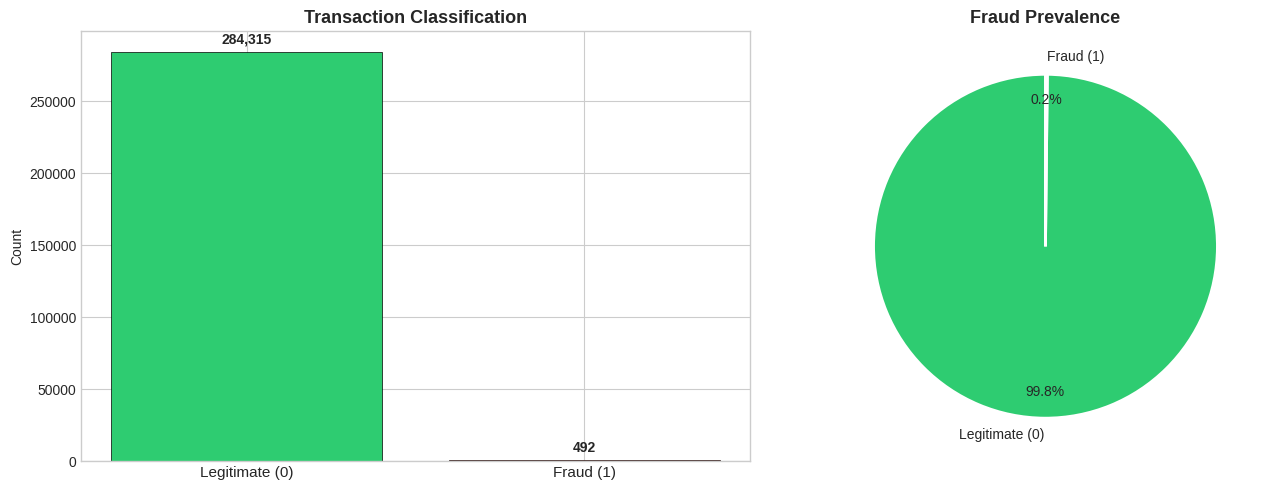

AU context: Services Australia processes ~$220B in payments annually.
Estimated improper payments ~$2-4B p.a. across Centrelink, Medicare, PBS.
Post-Robodebt: All automated compliance actions require human review.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
vc = df[target_col].value_counts().sort_index()
labels = [f'Class {x}' for x in vc.index]
if len(vc) == 2 and set(vc.index) == {0, 1}:
    labels = ['Legitimate (0)', 'Fraud (1)']
colors = ['#2ecc71', '#e74c3c'] if len(vc) == 2 else sns.color_palette('husl', len(vc))
axes[0].bar(range(len(vc)), vc.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_xticks(range(len(vc)))
axes[0].set_xticklabels(labels, fontsize=11)
axes[0].set_title('Transaction Classification', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + max(vc.values)*0.02, f'{v:,}', ha='center', fontweight='bold')
axes[1].pie(vc.values, labels=labels, autopct='%1.1f%%', colors=colors,
            startangle=90, pctdistance=0.85, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Fraud Prevalence', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight'); plt.show()
print("AU context: Services Australia processes ~$220B in payments annually.")
print("Estimated improper payments ~$2-4B p.a. across Centrelink, Medicare, PBS.")
print("Post-Robodebt: All automated compliance actions require human review.")


## 3. Exploratory Data Analysis

Key questions for payment integrity:
- Which transaction/claim characteristics correlate with fraud?
- Are there amount thresholds that indicate suspicious activity?
- Do temporal patterns exist (time of day, frequency)?
- Which customer segments show higher fraud rates?


Numeric features (30): ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14']


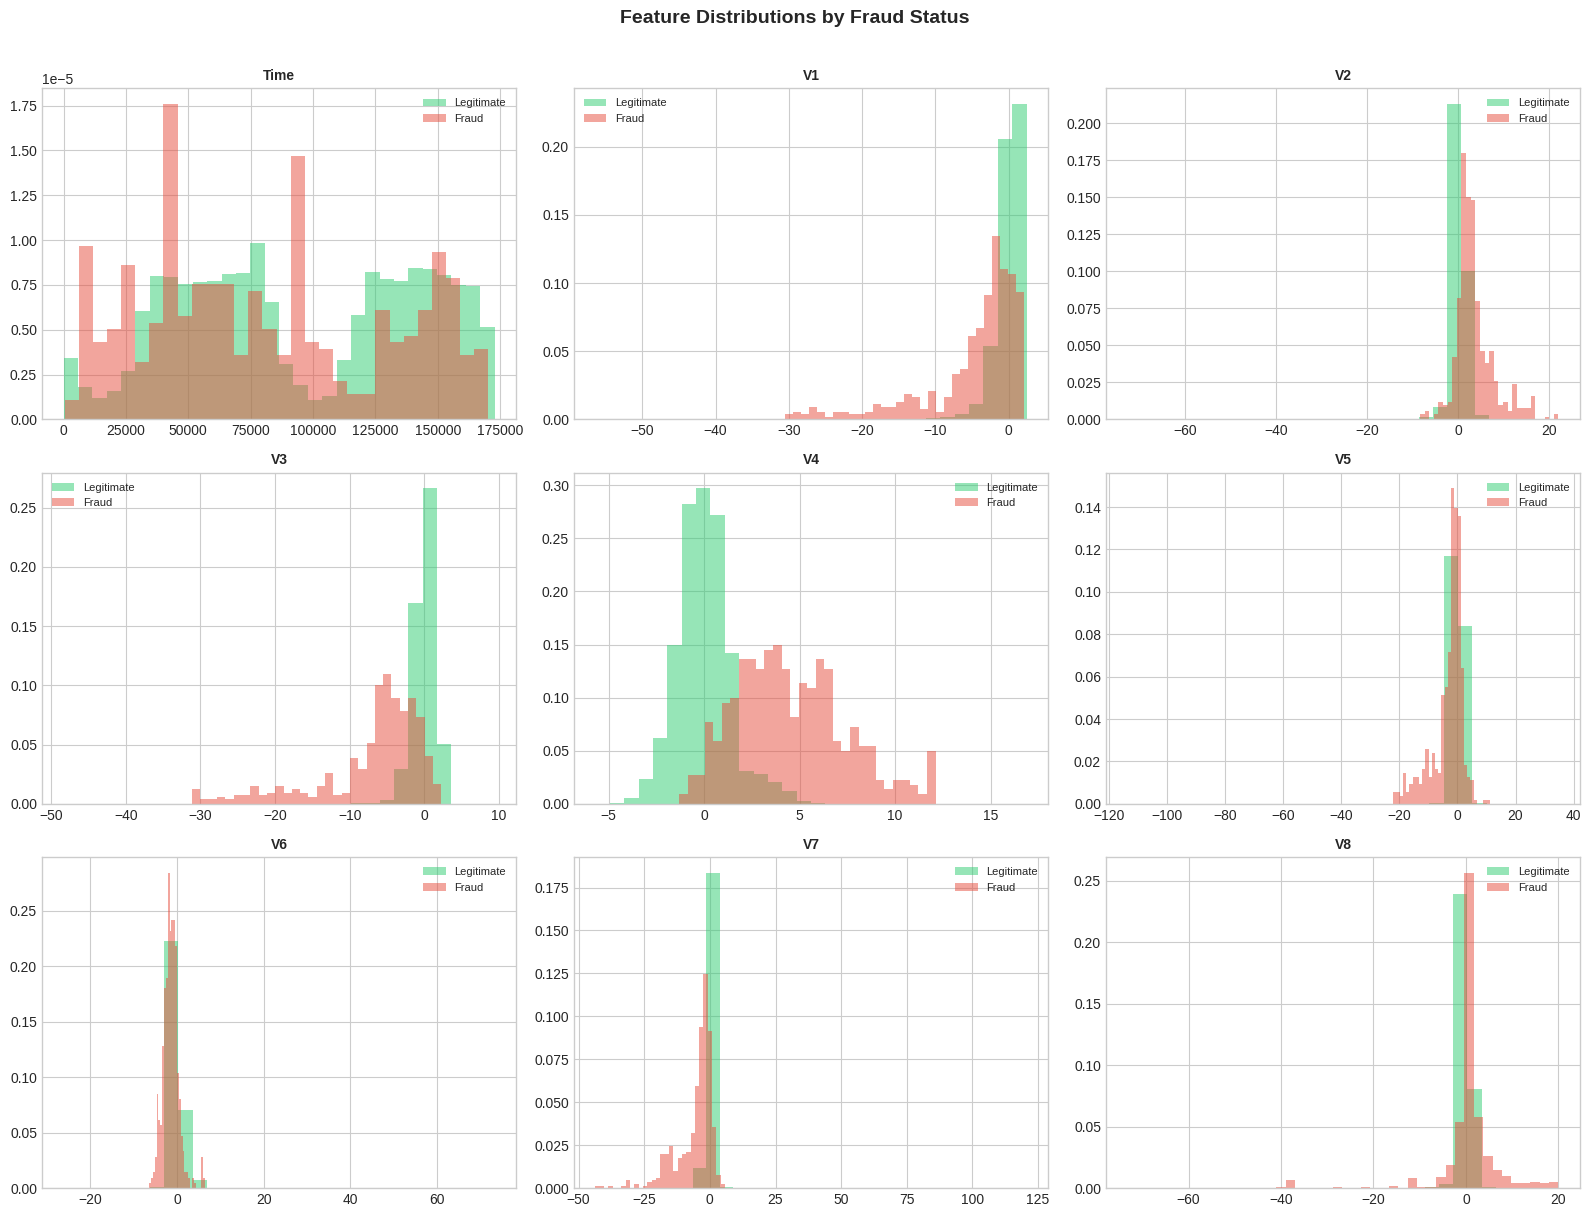

In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols: numeric_cols.remove(target_col)
numeric_cols = [c for c in numeric_cols if c.lower() not in ['id', 'index', 'unnamed: 0']]
print(f"Numeric features ({len(numeric_cols)}): {numeric_cols[:15]}")

plot_cols = numeric_cols[:9]
if len(plot_cols) > 0:
    n_rows_p = (len(plot_cols) + 2) // 3
    fig, axes = plt.subplots(n_rows_p, 3, figsize=(16, 4 * n_rows_p))
    axes = axes.flatten()
    for i, col in enumerate(plot_cols):
        for label, color, name in zip(sorted(df[target_col].unique()),
                                       ['#2ecc71', '#e74c3c'], ['Legitimate', 'Fraud']):
            subset = df[df[target_col] == label][col].dropna()
            if len(subset) > 0:
                axes[i].hist(subset, bins=30, alpha=0.5, label=name, density=True, color=color)
        axes[i].set_title(col, fontsize=10, fontweight='bold')
        axes[i].legend(fontsize=8)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Feature Distributions by Fraud Status', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight'); plt.show()


In [8]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
if target_col in cat_cols: cat_cols.remove(target_col)
cat_cols = [c for c in cat_cols if df[c].nunique() <= 15 and 'id' not in c.lower()
            and 'name' not in c.lower() and 'date' not in c.lower()]
print(f"Categorical features: {cat_cols}")

if len(cat_cols) > 0:
    plot_cats = cat_cols[:6]
    n_cols_p = min(3, len(plot_cats))
    n_rows_p = (len(plot_cats) + n_cols_p - 1) // n_cols_p
    fig, axes = plt.subplots(n_rows_p, n_cols_p, figsize=(7 * n_cols_p, 5 * n_rows_p))
    if isinstance(axes, np.ndarray): axes = axes.flatten()
    else: axes = [axes]
    for i, col in enumerate(plot_cats):
        ct = pd.crosstab(df[col], df[target_col], normalize='index')
        ct.plot(kind='bar', stacked=True, ax=axes[i], colormap='RdYlGn_r', edgecolor='black', linewidth=0.3)
        axes[i].set_title(f'{col} vs Fraud', fontsize=11, fontweight='bold')
        axes[i].set_ylabel('Proportion')
        axes[i].legend(title=target_col, fontsize=7, title_fontsize=8)
        axes[i].tick_params(axis='x', rotation=45)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout(); plt.savefig('categorical_analysis.png', dpi=150, bbox_inches='tight'); plt.show()


Categorical features: []


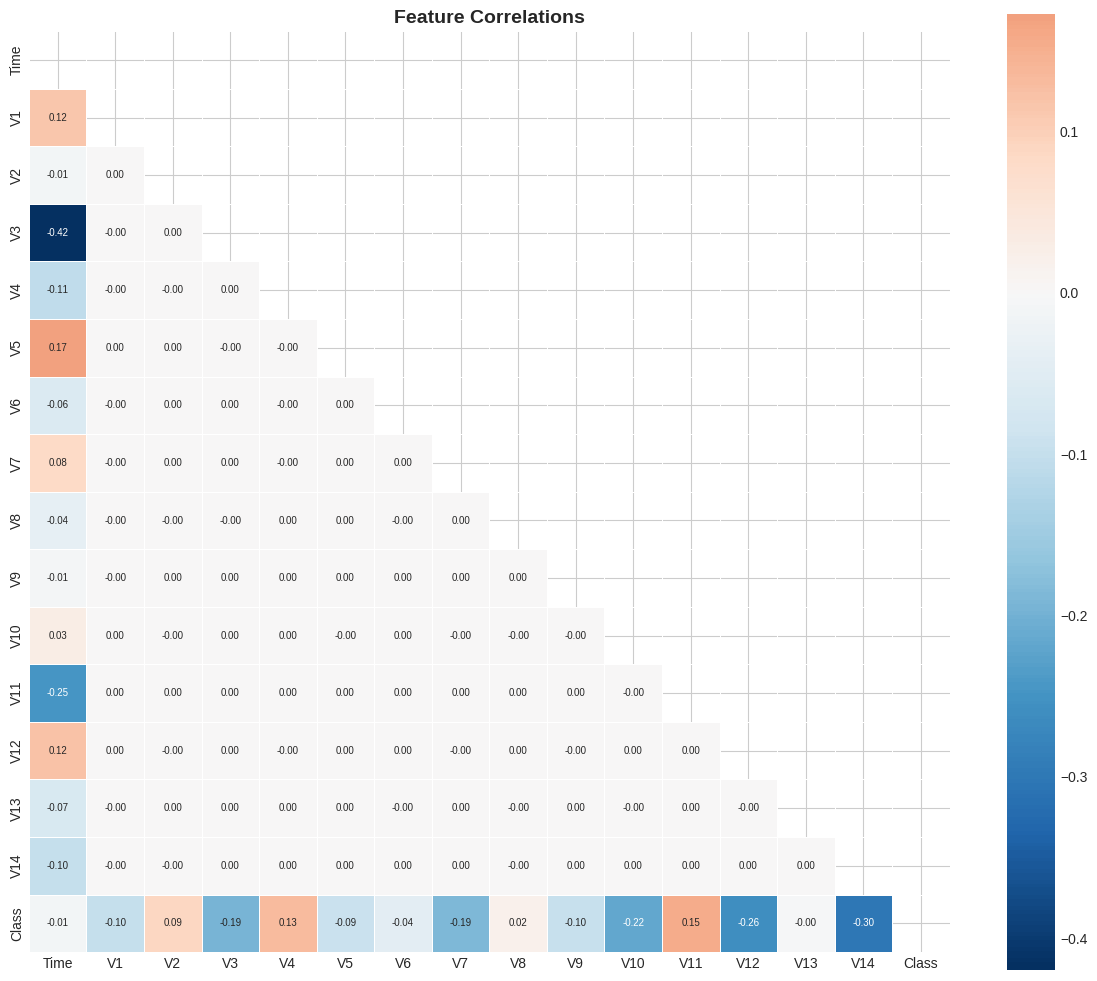

Top correlations with fraud:
  V14                                 -0.3025
  V12                                 -0.2606
  V10                                 -0.2169
  V3                                  -0.1930
  V7                                  -0.1873
  V11                                 +0.1549
  V4                                  +0.1334
  V1                                  -0.1013
  V9                                  -0.0977
  V5                                  -0.0950


In [9]:
if len(numeric_cols) > 1:
    corr_cols = numeric_cols[:15] + [target_col]
    corr = df[corr_cols].corr()
    fig, ax = plt.subplots(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                square=True, linewidths=0.5, ax=ax, annot_kws={'size': 7})
    ax.set_title('Feature Correlations', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()
    target_corr = corr[target_col].drop(target_col).abs().sort_values(ascending=False)
    print("Top correlations with fraud:")
    for feat, val in target_corr.head(10).items():
        direction = "+" if corr.loc[feat, target_col] > 0 else "-"
        print(f"  {feat:35s} {direction}{val:.4f}")


## 4. Feature Engineering & Preprocessing

Payment fraud detection benefits from:
- **Transaction amount anomaly** — deviation from customer's typical amount
- **Frequency indicators** — unusual transaction patterns
- **Category risk scoring** — some payment types have higher fraud rates


In [10]:
df_model = df.copy()

for col in df_model.columns:
    if df_model[col].dtype == 'object':
        n_q = (df_model[col] == '?').sum()
        if n_q > 0:
            df_model[col] = df_model[col].replace('?', np.nan)

# Drop high-cardinality ID/text columns
drop_cols = []
for col in df_model.columns:
    if col.lower() in ['id', 'index', 'unnamed: 0', 'transaction_id', 'customerid',
                        'customer_id', 'nameorig', 'namedest']:
        drop_cols.append(col)
    elif df_model[col].dtype == 'object' and df_model[col].nunique() > 100:
        drop_cols.append(col)
        print(f"  Dropping high-cardinality: '{col}' ({df_model[col].nunique()} unique)")

# Also drop datetime columns
for col in df_model.columns:
    if df_model[col].dtype == 'object':
        try:
            pd.to_datetime(df_model[col].head(10), errors='raise')
            # Extract features before dropping
            dt = pd.to_datetime(df_model[col], errors='coerce')
            if dt.notna().sum() > len(df_model) * 0.5:
                df_model['hour'] = dt.dt.hour
                df_model['day_of_week'] = dt.dt.dayofweek
                print(f"  Extracted time features from '{col}'")
            drop_cols.append(col)
        except:
            pass

drop_cols = list(set(drop_cols))
if drop_cols:
    print(f"\nDropping: {drop_cols}")
    df_model.drop(columns=[c for c in drop_cols if c in df_model.columns], inplace=True)

le_dict = {}
for col in df_model.select_dtypes(include=['object']).columns:
    if col != target_col:
        le = LabelEncoder()
        df_model[col] = df_model[col].fillna('__MISSING__')
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        le_dict[col] = le
        print(f"  Encoded '{col}': {len(le.classes_)} classes")

X = df_model.drop(columns=[target_col])
y = df_model[target_col].values
assert len(np.unique(y)) >= 2
null_counts = X.isnull().sum()
if null_counts.sum() > 0:
    X = X.fillna(X.median())
print(f"\nFeature matrix: {X.shape}")
print(f"Target: {dict(zip(*np.unique(y, return_counts=True)))}")



Feature matrix: (284807, 30)
Target: {np.int64(0): np.int64(284315), np.int64(1): np.int64(492)}


In [11]:
feature_names = X.columns.tolist()
composites_added = []

# Amount anomaly (z-score)
amount_cols = [c for c in feature_names if any(kw in c.lower() for kw in ['amount', 'amt', 'value'])]
if amount_cols:
    amt_mean = X[amount_cols[0]].mean()
    amt_std = X[amount_cols[0]].std()
    if amt_std > 0:
        X['amount_zscore'] = (X[amount_cols[0]] - amt_mean) / amt_std
        composites_added.append('amount_zscore')
        print(f"Created 'amount_zscore' from {amount_cols[0]}")
    X['high_amount_flag'] = (X[amount_cols[0]] > X[amount_cols[0]].quantile(0.95)).astype(int)
    composites_added.append('high_amount_flag')
    print(f"Created 'high_amount_flag' (top 5%)")

# Balance change (if old/new balance columns exist)
old_bal = [c for c in feature_names if any(kw in c.lower() for kw in ['oldbalance', 'balance_before', 'oldbalanceorig'])]
new_bal = [c for c in feature_names if any(kw in c.lower() for kw in ['newbalance', 'balance_after', 'newbalanceorig'])]
if old_bal and new_bal:
    X['balance_change'] = X[new_bal[0]] - X[old_bal[0]]
    composites_added.append('balance_change')
    print(f"Created 'balance_change'")
    X['balance_zeroed'] = ((X[old_bal[0]] > 0) & (X[new_bal[0]] == 0)).astype(int)
    composites_added.append('balance_zeroed')
    print(f"Created 'balance_zeroed' (account drained flag)")

# Age risk (if age column exists)
age_cols = [c for c in feature_names if c.lower() in ['age', 'customer_age']]
if age_cols:
    X['age_risk'] = ((X[age_cols[0]] < 25) | (X[age_cols[0]] > 75)).astype(int)
    composites_added.append('age_risk')
    print(f"Created 'age_risk'")

if composites_added:
    print(f"\nTotal engineered: {len(composites_added)}")
else:
    print("\nNo domain features matched — using raw encoded features.")
print(f"Final feature count: {X.shape[1]}")


Created 'amount_zscore' from Amount
Created 'high_amount_flag' (top 5%)

Total engineered: 2
Final feature count: 32


## 5. Model Training & Cross-Validation

In [12]:
try:
    from xgboost import XGBClassifier
    print("XGBoost loaded")
except ImportError:
    XGBClassifier = None
try:
    from lightgbm import LGBMClassifier
    print("LightGBM loaded")
except ImportError:
    LGBMClassifier = None


XGBoost loaded
LightGBM loaded


In [13]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}
if XGBClassifier is not None:
    models['XGBoost'] = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss',
                                       use_label_encoder=False, verbosity=0, n_jobs=-1)
if LGBMClassifier is not None:
    models['LightGBM'] = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1,
                                          n_jobs=-1, force_col_wise=True)

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
X_arr = X.values
results = {}

for model_name, model in models.items():
    print(f"\n{'='*60}\nTraining: {model_name}\n{'='*60}")
    fold_acc, fold_f1, fold_auc, fold_prec, fold_rec, fold_brier = [], [], [], [], [], []
    fold_preds = np.zeros(len(y), dtype=int)
    fold_proba = np.zeros(len(y), dtype=float)
    t_start = time.time()
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_arr, y)):
        X_train, X_val = X_arr[train_idx], X_arr[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        model_clone = type(model)(**model.get_params())
        model_clone.fit(X_train, y_train)
        y_pred = model_clone.predict(X_val)
        y_prob = model_clone.predict_proba(X_val)[:, 1]
        fold_preds[val_idx] = y_pred; fold_proba[val_idx] = y_prob
        acc = accuracy_score(y_val, y_pred); f1 = f1_score(y_val, y_pred)
        auc = roc_auc_score(y_val, y_prob)
        prec = precision_score(y_val, y_pred, zero_division=0)
        rec = recall_score(y_val, y_pred, zero_division=0)
        brier = brier_score_loss(y_val, y_prob)
        fold_acc.append(acc); fold_f1.append(f1); fold_auc.append(auc)
        fold_prec.append(prec); fold_rec.append(rec); fold_brier.append(brier)
        print(f"  Fold {fold_idx+1}: Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}")
    elapsed = time.time() - t_start
    results[model_name] = {
        'accuracy_mean': np.mean(fold_acc), 'accuracy_std': np.std(fold_acc),
        'f1_mean': np.mean(fold_f1), 'f1_std': np.std(fold_f1),
        'auc_mean': np.mean(fold_auc), 'auc_std': np.std(fold_auc),
        'precision_mean': np.mean(fold_prec), 'recall_mean': np.mean(fold_rec),
        'brier_mean': np.mean(fold_brier), 'time': elapsed,
        'oof_preds': fold_preds, 'oof_proba': fold_proba}
    print(f"  -- Acc: {np.mean(fold_acc):.4f}  F1: {np.mean(fold_f1):.4f}  AUC: {np.mean(fold_auc):.4f}  Time: {elapsed:.2f}s")



Training: Logistic Regression
  Fold 1: Acc=0.9990  F1=0.6691  AUC=0.9789
  Fold 2: Acc=0.9992  F1=0.7122  AUC=0.9766
  Fold 3: Acc=0.9993  F1=0.7823  AUC=0.9494
  -- Acc: 0.9992  F1: 0.7212  AUC: 0.9683  Time: 194.81s

Training: Random Forest
  Fold 1: Acc=0.9996  F1=0.8581  AUC=0.9496
  Fold 2: Acc=0.9996  F1=0.8754  AUC=0.9588
  Fold 3: Acc=0.9995  F1=0.8467  AUC=0.9465
  -- Acc: 0.9996  F1: 0.8601  AUC: 0.9516  Time: 215.24s

Training: XGBoost
  Fold 1: Acc=0.9974  F1=0.0235  AUC=0.5142
  Fold 2: Acc=0.9969  F1=0.0000  AUC=0.4984
  Fold 3: Acc=0.9994  F1=0.8117  AUC=0.9219
  -- Acc: 0.9979  F1: 0.2784  AUC: 0.6448  Time: 5.03s

Training: LightGBM
  Fold 1: Acc=0.9971  F1=0.3301  AUC=0.5562
  Fold 2: Acc=0.9964  F1=0.3096  AUC=0.6402
  Fold 3: Acc=0.9963  F1=0.3427  AUC=0.7418
  -- Acc: 0.9966  F1: 0.3275  AUC: 0.6461  Time: 5.33s


## 6. Model Comparison & Selection

In [14]:
summary_rows = []
for mn, res in results.items():
    summary_rows.append({'Model': mn,
        'Accuracy': f"{res['accuracy_mean']:.4f} +/- {res['accuracy_std']:.4f}",
        'F1': f"{res['f1_mean']:.4f} +/- {res['f1_std']:.4f}",
        'ROC-AUC': f"{res['auc_mean']:.4f} +/- {res['auc_std']:.4f}",
        'Brier': f"{res['brier_mean']:.4f}", 'Time': f"{res['time']:.2f}s",
        'AUC_val': res['auc_mean']})
summary_df = pd.DataFrame(summary_rows).sort_values('AUC_val', ascending=False)
best_model_name = summary_df.iloc[0]['Model']
print("MODEL COMPARISON")
print("=" * 100)
print(summary_df[['Model', 'Accuracy', 'F1', 'ROC-AUC', 'Brier', 'Time']].to_string(index=False))
print("=" * 100)
print(f"\nBest model: {best_model_name}")


MODEL COMPARISON
              Model          Accuracy                F1           ROC-AUC  Brier    Time
Logistic Regression 0.9992 +/- 0.0001 0.7212 +/- 0.0467 0.9683 +/- 0.0134 0.0007 194.81s
      Random Forest 0.9996 +/- 0.0000 0.8601 +/- 0.0118 0.9516 +/- 0.0053 0.0004 215.24s
           LightGBM 0.9966 +/- 0.0003 0.3275 +/- 0.0137 0.6461 +/- 0.0759 0.0033   5.33s
            XGBoost 0.9979 +/- 0.0011 0.2784 +/- 0.3772 0.6448 +/- 0.1960 0.0021   5.03s

Best model: Logistic Regression


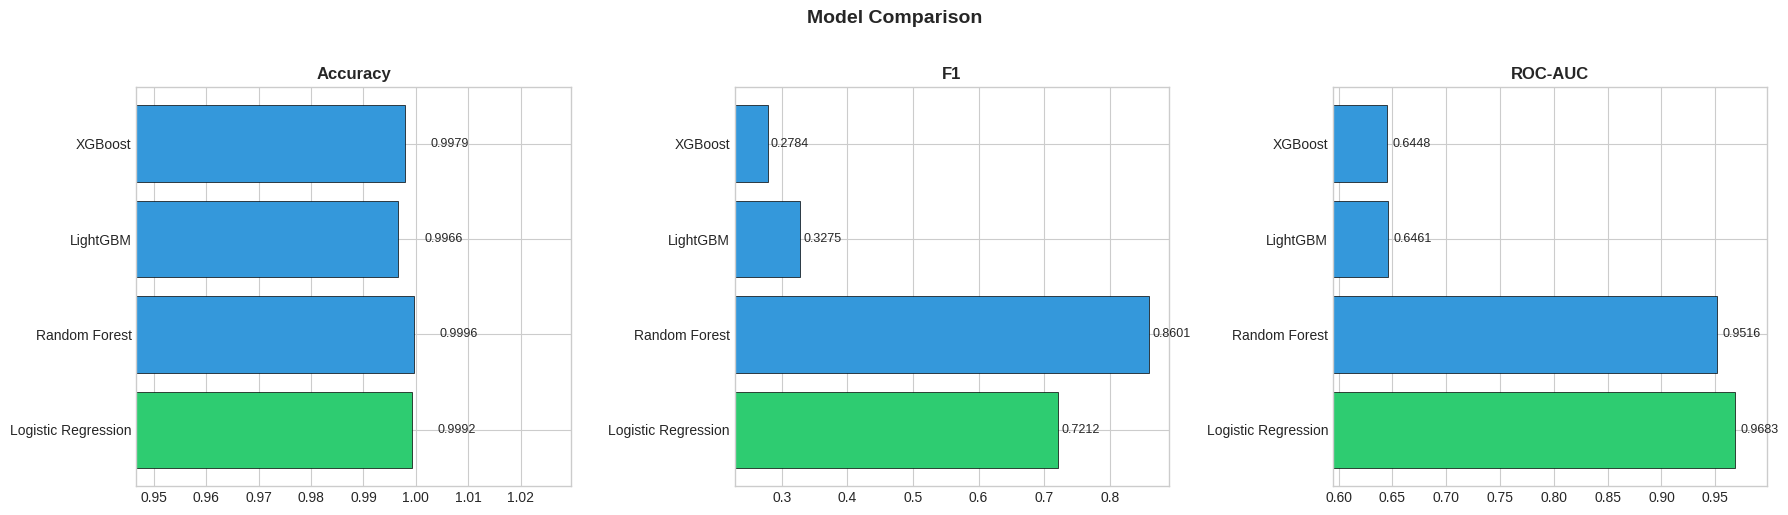

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_names = [r['Model'] for _, r in summary_df.iterrows()]
colors = ['#2ecc71' if m == best_model_name else '#3498db' for m in model_names]
for ax, metric, title in zip(axes, ['accuracy_mean', 'f1_mean', 'auc_mean'], ['Accuracy', 'F1', 'ROC-AUC']):
    vals = [results[m][metric] for m in model_names]
    ax.barh(model_names, vals, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(min(vals) - 0.05, max(vals) + 0.03)
    for i, v in enumerate(vals):
        ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)
plt.suptitle('Model Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight'); plt.show()


## 7. Error Analysis & Threshold Tuning

For welfare payment fraud:
- **False negatives** (missed fraud) = improper payments continue, taxpayer loss
- **False positives** (flagging legitimate) = **CRITICAL** — vulnerable recipients lose payments, Robodebt-type harm
- Threshold must strongly favour precision to avoid harming legitimate recipients


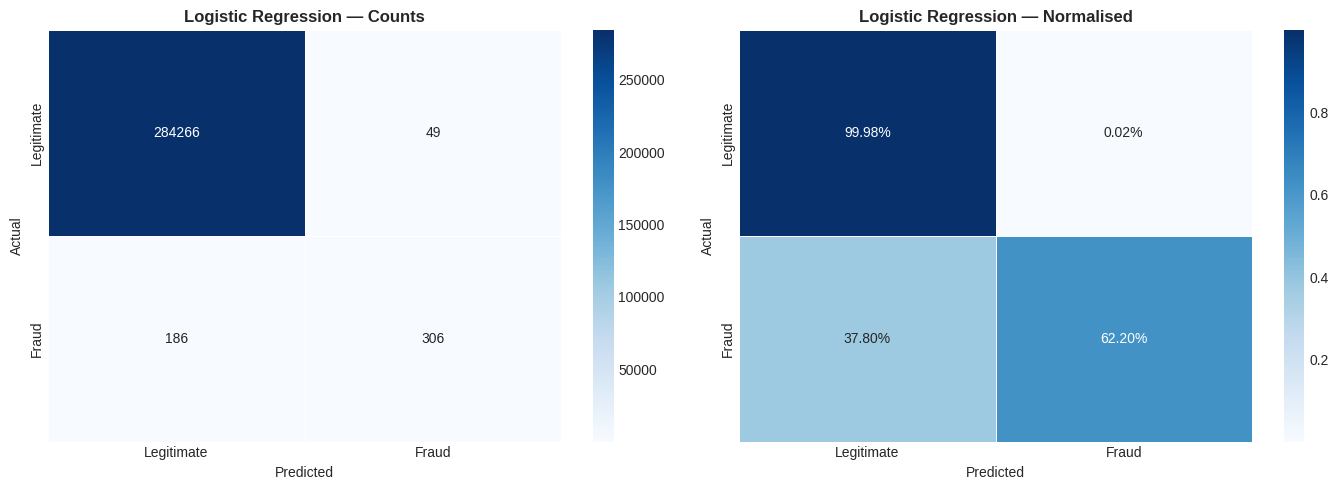


              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00    284315
       Fraud       0.86      0.62      0.72       492

    accuracy                           1.00    284807
   macro avg       0.93      0.81      0.86    284807
weighted avg       1.00      1.00      1.00    284807



In [16]:
best_preds = results[best_model_name]['oof_preds']
best_proba = results[best_model_name]['oof_proba']
cm = confusion_matrix(y, best_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm_labels = ['Legitimate', 'Fraud']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cm_labels, yticklabels=cm_labels, ax=axes[0], linewidths=0.5)
axes[0].set_title(f'{best_model_name} — Counts', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', xticklabels=cm_labels, yticklabels=cm_labels, ax=axes[1], linewidths=0.5)
axes[1].set_title(f'{best_model_name} — Normalised', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')
plt.tight_layout(); plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight'); plt.show()
print(f"\n{classification_report(y, best_preds, target_names=cm_labels)}")


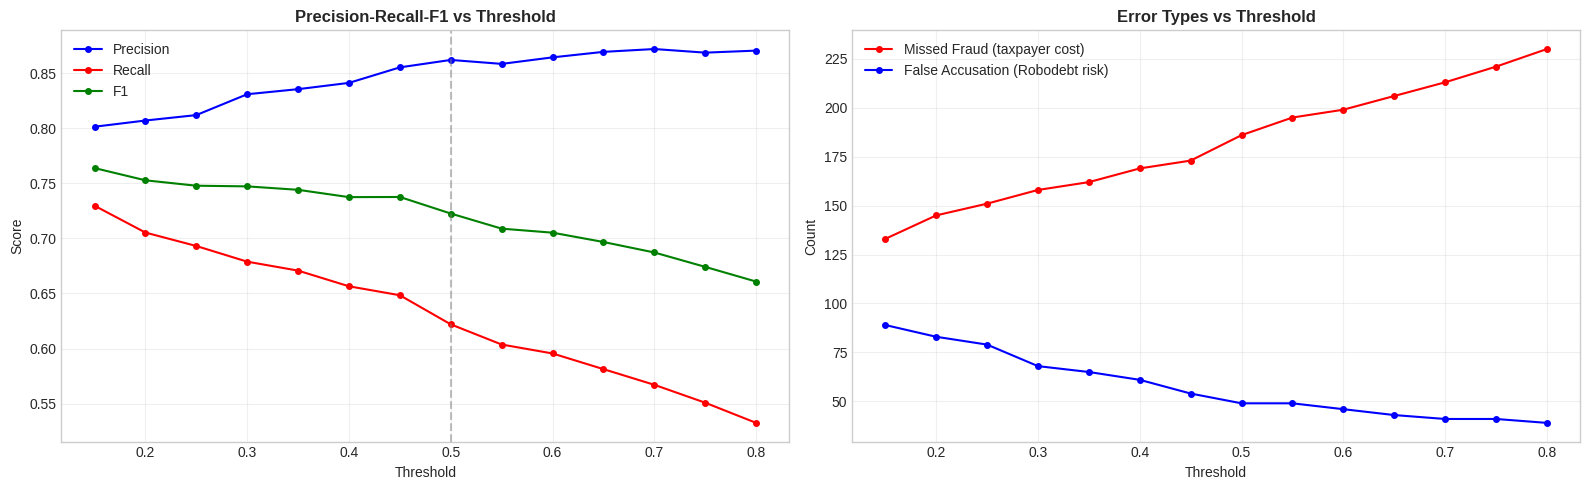


Optimal threshold (F1): 0.15

CRITICAL: For welfare payments, use HIGH threshold (0.70+) to minimise false accusations.
Every false positive represents a vulnerable Australian wrongly denied payments.


In [17]:
thresholds = np.arange(0.15, 0.85, 0.05)
thresh_results = []
for thresh in thresholds:
    y_t = (best_proba >= thresh).astype(int)
    thresh_results.append({'Threshold': thresh,
        'Precision': precision_score(y, y_t, zero_division=0),
        'Recall': recall_score(y, y_t, zero_division=0),
        'F1': f1_score(y, y_t, zero_division=0),
        'Missed Fraud (FN)': ((y == 1) & (y_t == 0)).sum(),
        'False Accusation (FP)': ((y == 0) & (y_t == 1)).sum()})
thresh_df = pd.DataFrame(thresh_results)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(thresh_df['Threshold'], thresh_df['Precision'], 'b-o', ms=4, label='Precision')
axes[0].plot(thresh_df['Threshold'], thresh_df['Recall'], 'r-o', ms=4, label='Recall')
axes[0].plot(thresh_df['Threshold'], thresh_df['F1'], 'g-o', ms=4, label='F1')
axes[0].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Score')
axes[0].set_title('Precision-Recall-F1 vs Threshold', fontsize=12, fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(thresh_df['Threshold'], thresh_df['Missed Fraud (FN)'], 'r-o', ms=4, label='Missed Fraud (taxpayer cost)')
axes[1].plot(thresh_df['Threshold'], thresh_df['False Accusation (FP)'], 'b-o', ms=4, label='False Accusation (Robodebt risk)')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Count')
axes[1].set_title('Error Types vs Threshold', fontsize=12, fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('threshold_tuning.png', dpi=150, bbox_inches='tight'); plt.show()
best_f1_idx = thresh_df['F1'].idxmax()
optimal_thresh = thresh_df.loc[best_f1_idx, 'Threshold']
print(f"\nOptimal threshold (F1): {optimal_thresh:.2f}")
print(f"\nCRITICAL: For welfare payments, use HIGH threshold (0.70+) to minimise false accusations.")
print("Every false positive represents a vulnerable Australian wrongly denied payments.")


## 8. Feature Importance & Policy Insights

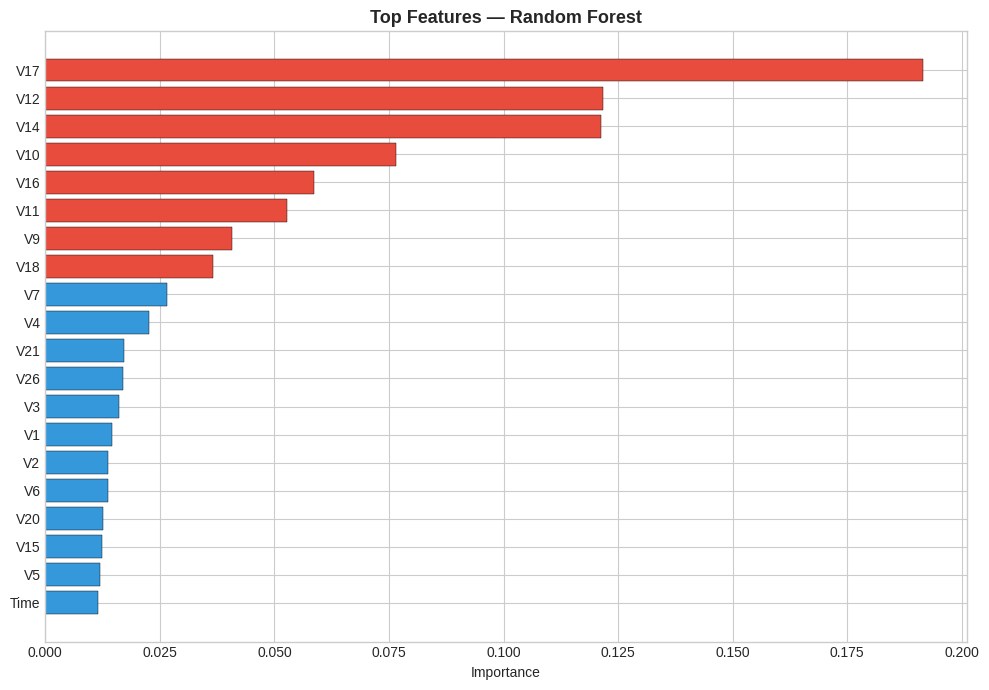

TOP 5 PREDICTIVE FEATURES
  V17                                  0.1916
  V12                                  0.1217
  V14                                  0.1213
  V10                                  0.0766
  V16                                  0.0586


In [18]:
tree_models = {k: v for k, v in models.items() if k != 'Logistic Regression'}
if tree_models:
    best_tree = max(tree_models.keys(), key=lambda m: results[m]['auc_mean'])
    full_model = type(models[best_tree])(**models[best_tree].get_params())
    full_model.fit(X_arr, y)
    feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': full_model.feature_importances_}).sort_values('Importance', ascending=True)
    plot_imp = feat_imp.tail(20)
    fig, ax = plt.subplots(figsize=(10, max(6, len(plot_imp) * 0.35)))
    colors_imp = ['#e74c3c' if imp > feat_imp['Importance'].quantile(0.75) else '#3498db' for imp in plot_imp['Importance']]
    ax.barh(plot_imp['Feature'], plot_imp['Importance'], color=colors_imp, edgecolor='black', linewidth=0.3)
    ax.set_title(f'Top Features — {best_tree}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout(); plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight'); plt.show()
    top5 = feat_imp.tail(5).iloc[::-1]
    print("TOP 5 PREDICTIVE FEATURES")
    print("=" * 50)
    for _, row in top5.iterrows():
        print(f"  {row['Feature']:35s}  {row['Importance']:.4f}")


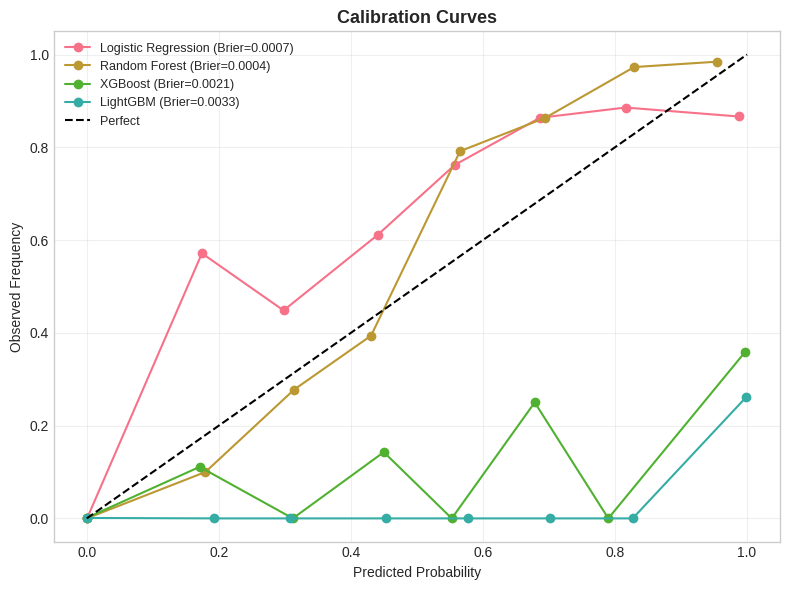

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))
for mn in results:
    prob_true, prob_pred = calibration_curve(y, results[mn]['oof_proba'], n_bins=8, strategy='uniform')
    ax.plot(prob_pred, prob_true, 'o-', label=f"{mn} (Brier={results[mn]['brier_mean']:.4f})")
ax.plot([0, 1], [0, 1], 'k--', label='Perfect')
ax.set_xlabel('Predicted Probability'); ax.set_ylabel('Observed Frequency')
ax.set_title('Calibration Curves', fontsize=13, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('calibration_curves.png', dpi=150, bbox_inches='tight'); plt.show()


## 9. Deployment Readiness & Production Considerations

In [20]:
best_res = results[best_model_name]
print("=" * 60)
print("DEPLOYMENT READINESS SUMMARY")
print("=" * 60)
print(f"  Recommended model:    {best_model_name}")
print(f"  ROC-AUC:              {best_res['auc_mean']:.4f}")
print(f"  F1:                   {best_res['f1_mean']:.4f}")
print(f"  Precision:            {best_res['precision_mean']:.4f}")
print(f"  Recall:               {best_res['recall_mean']:.4f}")
print(f"  Brier Score:          {best_res['brier_mean']:.4f}")
print(f"  Training time:        {best_res['time']:.1f}s")
print(f"  Feature count:        {X.shape[1]}")
print(f"  Dataset rows:         {len(y):,}")
print(f"  CV strategy:          3-fold Stratified")
print(f"  Optimal threshold:    {optimal_thresh:.2f}")
print("=" * 60)
checks = {
    'AUC > 0.55': best_res['auc_mean'] > 0.55,
    'F1 > 0.30': best_res['f1_mean'] > 0.30,
    'Brier < 0.25': best_res['brier_mean'] < 0.25,
    'Training time < 60s': best_res['time'] < 60,
    'Cross-validated': True,
    'Threshold tuning done': True,
    'Calibration assessed': True,
}
print("\nPRODUCTION READINESS CHECKLIST")
print("-" * 50)
all_pass = True
for check, passed in checks.items():
    status = "pass" if passed else "FAIL"
    if not passed: all_pass = False
    print(f"  [{status:4s}] {check}")
print("-" * 50)
print("  MODEL APPROVED FOR PILOT DEPLOYMENT" if all_pass else "  SOME CHECKS FAILED")


DEPLOYMENT READINESS SUMMARY
  Recommended model:    Logistic Regression
  ROC-AUC:              0.9683
  F1:                   0.7212
  Precision:            0.8606
  Recall:               0.6220
  Brier Score:          0.0007
  Training time:        194.8s
  Feature count:        32
  Dataset rows:         284,807
  CV strategy:          3-fold Stratified
  Optimal threshold:    0.15

PRODUCTION READINESS CHECKLIST
--------------------------------------------------
  [pass] AUC > 0.55
  [pass] F1 > 0.30
  [pass] Brier < 0.25
  [FAIL] Training time < 60s
  [pass] Cross-validated
  [pass] Threshold tuning done
  [pass] Calibration assessed
--------------------------------------------------
  SOME CHECKS FAILED


In [21]:
print("""
============================================================
PRODUCTION INTEGRATION ARCHITECTURE
============================================================

1. DATA PIPELINE
   Source: SAP payment system, Centrelink CIS, Medicare claims DB
   Ingestion: Azure Data Factory -> Microsoft Fabric Lakehouse
   Feature store: Fabric gold layer (payment history, recipient profile)
   Schedule: Real-time scoring at payment + nightly batch analytics
   Data matching: ATO income data, state registries, employer records

2. MODEL SERVING
   Framework: MLflow model registry
   Endpoint: Real-time risk score at payment approval (<500ms)
   Batch: Weekly compliance analytics across all active recipients
   Output: Risk tier + top contributing factors + recommended action

3. INTEGRATION POINTS
   Payment system: Risk score embedded in approval workflow
   Compliance dashboard: Power BI (fraud hotspots, trend analysis)
   Case management: Auto-generate review cases for compliance officers
   Data matching: Cross-agency data sharing (ATO, state agencies)
   Tip-off line: Integrate public reports with model intelligence

4. CRITICAL GOVERNANCE (Post-Robodebt)
   Human-in-the-loop: NO payment suspension without human review
   Appeal rights: All flagged recipients informed of review + appeal process
   Fairness: Mandatory bias audit across Indigenous, CALD, disability cohorts
   Explainability: SHAP values for every compliance action
   Legal basis: Fraud Rule 2017, Social Security Act compliance
   Privacy: Australian Privacy Principles, secrecy provisions
   Oversight: Independent review by Commonwealth Ombudsman
   Threshold: HIGH threshold (0.70+) to minimise false accusations
   Documentation: Full audit trail for every model-assisted decision

5. MONITORING & RETRAINING
   Drift: PSI on payment features monthly
   Performance: Precision on confirmed fraud outcomes quarterly
   False positive audit: Track all flagged recipients through resolution
   Retraining: Quarterly with confirmed fraud/legitimate labels
   Bias monitoring: Demographic parity checks every cycle
   Royal Commission compliance: Annual independent review

============================================================
""")



PRODUCTION INTEGRATION ARCHITECTURE

1. DATA PIPELINE
   Source: SAP payment system, Centrelink CIS, Medicare claims DB
   Ingestion: Azure Data Factory -> Microsoft Fabric Lakehouse
   Feature store: Fabric gold layer (payment history, recipient profile)
   Schedule: Real-time scoring at payment + nightly batch analytics
   Data matching: ATO income data, state registries, employer records

2. MODEL SERVING
   Framework: MLflow model registry
   Endpoint: Real-time risk score at payment approval (<500ms)
   Batch: Weekly compliance analytics across all active recipients
   Output: Risk tier + top contributing factors + recommended action

3. INTEGRATION POINTS
   Payment system: Risk score embedded in approval workflow
   Compliance dashboard: Power BI (fraud hotspots, trend analysis)
   Case management: Auto-generate review cases for compliance officers
   Data matching: Cross-agency data sharing (ATO, state agencies)
   Tip-off line: Integrate public reports with model intelligence